In [1]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Academics/Winter 2026/Bayes/Group Proj Personal/CMAPSSData/'

Mounted at /content/drive


# Task
Process the CMAPSS training data to prepare it for Dynamic Bayesian Network learning.

1.  **Load Data**: Load `train_FD001.txt` from the path `"/content/drive/MyDrive/Academics/Winter 2026/Bayes/Group Proj Personal/CMAPSSData/"`. Assign column names: `unit`, `time`, `os1`, `os2`, `os3`, and `s1` through `s21`.
2.  **Calculate RUL**: For each unit, calculate Remaining Useful Life (RUL) as the maximum time cycle minus the current time cycle.
3.  **Feature Engineering**: Generate 5-cycle rolling mean and rolling slope (or difference) features for the sensor columns to capture trends.
4.  **Define Latent State**: Create a categorical `Health_State` variable by binning the RUL (e.g., >100: 'Healthy', 50-100: 'Degradation', <50: 'Critical').
5.  **Discretization**: Discretize all continuous sensor readings and generated trend features into 5 bins using quantile binning.
6.  **Temporal Analysis**: Compute and visualize the lagged correlations (e.g., Pearson correlation between $t$ and $t+1$) for key features to identify potential temporal edges for the DBN.
7.  **Summary**: Display the first few rows of the processed dataframe and print a summary of the new discrete features and health states.

## Load CMAPSS Data

### Subtask:
Load the CMAPSS training data (train_FD001.txt) from the specified path and assign column names.


**Reasoning**:
Load the CMAPSS training data as per instructions, defining column names and reading the file with whitespace separator.



In [2]:
import pandas as pd

# Define column names
cols = ['unit', 'time', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

# Load the training data
train_fd001 = pd.read_csv(path + 'train_FD001.txt', sep='\s+', header=None, names=cols)

# Display the first 5 rows
train_fd001.head()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2138843087.py:7: SyntaxWarning: invalid escape sequence '\s'
  train_fd001 = pd.read_csv(path + 'train_FD001.txt', sep='\s+', header=None, names=cols)


,unit,time,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


**Reasoning**:
The code produced a SyntaxWarning because the regex pattern '\s+' was passed as a regular string, which Python 3.12+ flags as an invalid escape sequence. I will fix this by using a raw string `r'\s+'` for the `sep` argument.



In [3]:
import pandas as pd

# Define column names
cols = ['unit', 'time', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

# Load the training data
# Using a raw string r'\s+' to avoid SyntaxWarning about invalid escape sequences
train_fd001 = pd.read_csv(path + 'train_FD001.txt', sep=r'\s+', header=None, names=cols)

# Display the first 5 rows
train_fd001.head()

,unit,time,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Calculate RUL

### Subtask:
Calculate the Remaining Useful Life (RUL) for each unit.


**Reasoning**:
Calculate RUL by finding the maximum time cycle for each unit and subtracting the current time cycle.



In [4]:
# Calculate max cycle for each unit
max_cycle = train_fd001.groupby('unit')['time'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

# Merge max_cycle back to the original dataframe
train_fd001 = train_fd001.merge(max_cycle, on='unit', how='left')

# Calculate RUL
train_fd001['RUL'] = train_fd001['max_cycle'] - train_fd001['time']

# Display first few rows with relevant columns
train_fd001[['unit', 'time', 'max_cycle', 'RUL']].head()

,unit,time,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


## Generate Trend Features

### Subtask:
Generate rolling mean and difference features for sensor columns to capture temporal trends.


**Reasoning**:
I will calculate the 5-cycle rolling mean and the difference for each sensor column (s1-s21) grouped by 'unit' to capture temporal trends. Then, I will remove the rows with NaN values introduced by these operations.



In [5]:
# Define the list of sensor columns
sensor_cols = [f's{i}' for i in range(1, 22)]

# Calculate rolling mean and difference for each sensor column
for col in sensor_cols:
    # 5-cycle rolling mean
    train_fd001[f'{col}_mean'] = train_fd001.groupby('unit')[col].transform(lambda x: x.rolling(window=5).mean())
    # Difference (instantaneous slope)
    train_fd001[f'{col}_diff'] = train_fd001.groupby('unit')[col].transform(lambda x: x.diff())

# Drop rows with NaN values introduced by the rolling window and lag operations
train_fd001.dropna(inplace=True)

# Display the first few rows to verify the new features
train_fd001.head()

,unit,time,os1,os2,os3,s1,s2,s3,s4,s5,...,s17_mean,s17_diff,s18_mean,s18_diff,s19_mean,s19_diff,s20_mean,s20_diff,s21_mean,s21_diff
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,391.8,1.0,2388.0,0.0,100.0,0.0,38.958,0.02,23.39302,0.0305
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,391.6,-2.0,2388.0,0.0,100.0,0.0,38.942,0.08,23.38260,-0.0375
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,391.6,1.0,2388.0,0.0,100.0,0.0,38.962,0.12,23.37336,0.0105
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,391.8,-1.0,2388.0,0.0,100.0,0.0,38.966,-0.13,23.36664,-0.0668
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,391.8,1.0,2388.0,0.0,100.0,0.0,39.000,0.08,23.37318,0.0960


## Define Latent Health State

### Subtask:
Create a categorical `Health_State` variable by binning the RUL into discrete states (Healthy, Degradation, Critical).


**Reasoning**:
I will import numpy and use `np.select` to create the `Health_State` categorical column based on the specified RUL thresholds. Then, I will display the distribution of health states and the first few rows to verify the assignment.



In [6]:
import numpy as np

# Define conditions for Health_State
conditions = [
    (train_fd001['RUL'] > 100),
    (train_fd001['RUL'] >= 50) & (train_fd001['RUL'] <= 100),
    (train_fd001['RUL'] < 50)
]

# Define corresponding choices
choices = ['Healthy', 'Degradation', 'Critical']

# Create the Health_State column
train_fd001['Health_State'] = np.select(conditions, choices, default='Unknown')

# Print the distribution of Health States
print("Health State Distribution:")
print(train_fd001['Health_State'].value_counts())

# Display the first 5 rows to verify
train_fd001[['unit', 'time', 'RUL', 'Health_State']].head()

Health State Distribution:
Health_State
Healthy        10131
Degradation     5100
Critical        5000
Name: count, dtype: int64


,unit,time,RUL,Health_State
4,1,5,187,Healthy
5,1,6,186,Healthy
6,1,7,185,Healthy
7,1,8,184,Healthy
8,1,9,183,Healthy


## Discretize Features

### Subtask:
Discretize continuous sensor readings and generated trend features into 5 bins using quantile binning.


**Reasoning**:
I will identify the continuous columns (operational settings, sensors, and trend features), create a copy of the dataframe `df_discrete`, and apply quantile binning to these columns. Finally, I will display the first few rows and check the number of bins for a few columns to verify the discretization.



In [7]:
# Create a copy of the dataframe for discretization
df_discrete = train_fd001.copy()

# Identify columns to be discretized
# Operational settings and Sensor columns
continuous_cols = ['os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]
# Trend features (ending in _mean or _diff)
sensor_cols = [f's{i}' for i in range(1, 22)]
trend_cols = [f'{col}_mean' for col in sensor_cols] + [f'{col}_diff' for col in sensor_cols]

# Combine all lists
cols_to_discretize = continuous_cols + trend_cols

# Apply quantile binning
for col in cols_to_discretize:
    # Using duplicates='drop' handles columns with low variance or constant values
    df_discrete[col] = pd.qcut(df_discrete[col], q=5, labels=False, duplicates='drop')

# Display the first 5 rows
print("First 5 rows of df_discrete:")
print(df_discrete.head())

# Verify discretization by checking unique values for sample columns
print("\nUnique bin counts for sample columns:")
for col in ['s2', 's2_mean', 'os1']:
    print(f"{col}: {df_discrete[col].nunique()}")

First 5 rows of df_discrete:
   unit  time  os1  os2  os3  s1  s2  s3  s4  s5  ...  s17_diff  s18_mean  \
4     1     5    0    1  NaN NaN   1   0   2 NaN  ...         2       NaN   
5     1     6    0    1  NaN NaN   0   0   0 NaN  ...         0       NaN   
6     1     7    3    2  NaN NaN   1   3   0 NaN  ...         2       NaN   
7     1     8    0    3  NaN NaN   2   0   0 NaN  ...         0       NaN   
8     1     9    3    2  NaN NaN   0   2   0 NaN  ...         2       NaN   

   s18_diff  s19_mean  s19_diff  s20_mean  s20_diff  s21_mean  s21_diff  \
4       NaN       NaN       NaN         4         2         4         3   
5       NaN       NaN       NaN         3         3         4         1   
6       NaN       NaN       NaN         4         4         4         2   
7       NaN       NaN       NaN         4         0         3         1   
8       NaN       NaN       NaN         4         3         4         4   

   Health_State  
4       Healthy  
5       Healthy  
6  

## Analyze Temporal Correlations

### Subtask:
Compute and visualize lagged correlations (t vs t+1) for sensor features to identify potential temporal edges.


**Reasoning**:
Compute lagged correlations (t vs t+1) for sensor features, visualize them with a heatmap, and identify the top temporal dependencies.



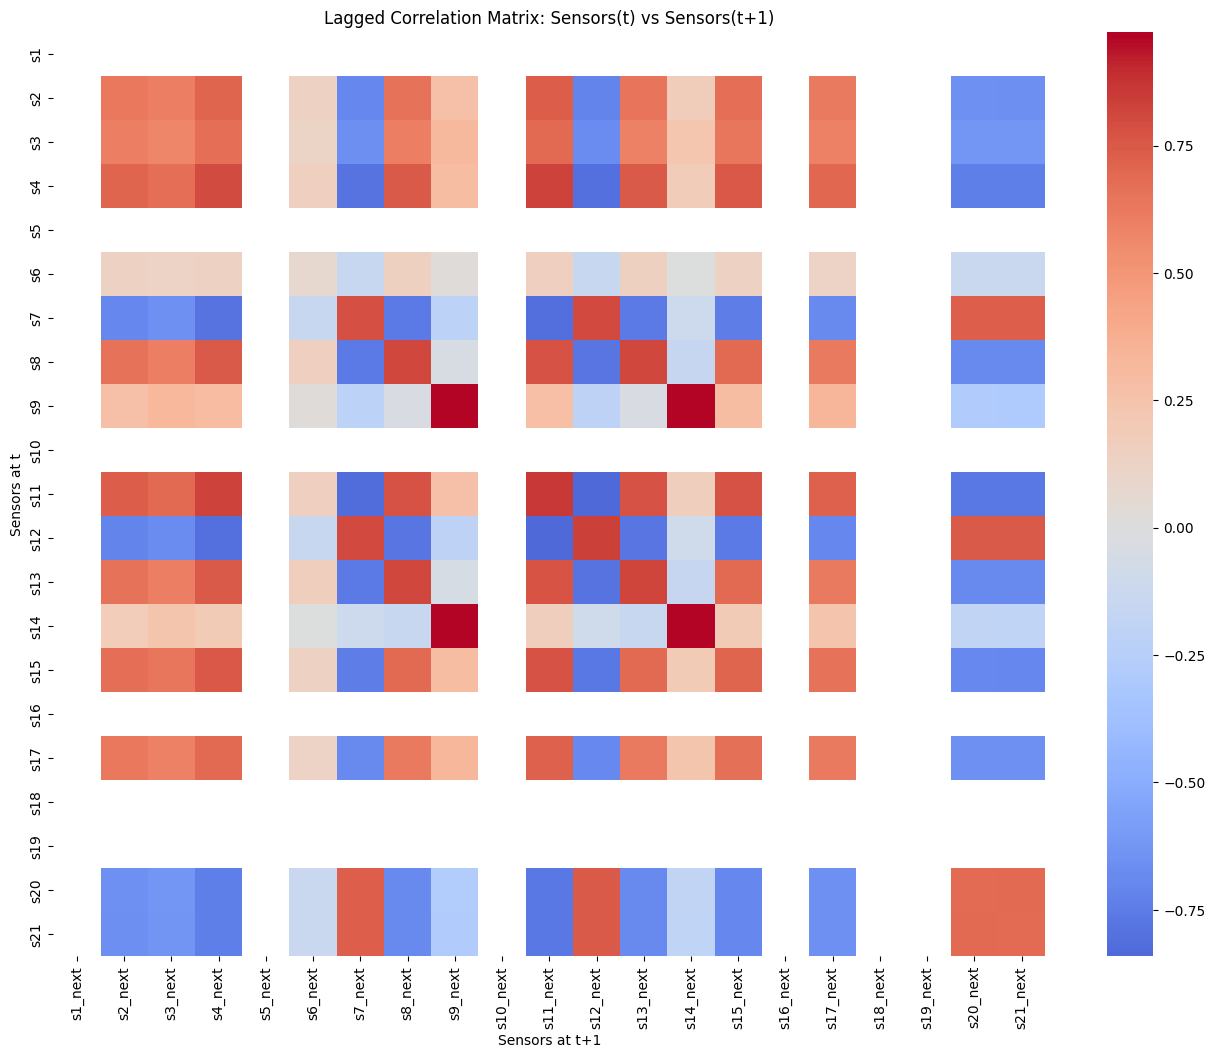

Top 10 Temporal Correlations (t -> t+1):
s14_next  s14    0.972773
s9_next   s9     0.964342
s14_next  s9     0.960725
s9_next   s14    0.960277
s11_next  s11    0.854068
s12_next  s11   -0.840846
s11_next  s12   -0.838804
s12_next  s12    0.832750
s11_next  s4     0.826824
s4_next   s11    0.826452
dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define sensor columns
sensor_cols = [f's{i}' for i in range(1, 22)]

# 2. Create lagged features (t+1)
# We group by unit to ensure we don't shift values across different engines
df_t = train_fd001[['unit'] + sensor_cols].copy()
df_t_plus_1 = df_t.groupby('unit')[sensor_cols].shift(-1).add_suffix('_next')

# 3. Combine t and t+1 features
df_lagged = pd.concat([df_t[sensor_cols], df_t_plus_1], axis=1).dropna()

# 4. Compute Correlation Matrix
# We are interested in the correlation between s_i(t) and s_j(t+1)
full_corr = df_lagged.corr()

# Extract the submatrix: rows = current sensors, cols = next sensors
next_cols = [c for c in df_lagged.columns if c.endswith('_next')]
lagged_corr = full_corr.loc[sensor_cols, next_cols]

# 5. Visualize with Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(lagged_corr, cmap='coolwarm', center=0, annot=False)
plt.title('Lagged Correlation Matrix: Sensors(t) vs Sensors(t+1)')
plt.xlabel('Sensors at t+1')
plt.ylabel('Sensors at t')
plt.show()

# 6. Identify Top Temporal Correlations
# Unstack and sort by absolute correlation
corr_pairs = lagged_corr.unstack()
sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

print("Top 10 Temporal Correlations (t -> t+1):")
print(sorted_pairs.head(10))

## Summary

### Subtask:
Display the first few rows of the processed dataframe and print a summary of the new discrete features and health states.


**Reasoning**:
I will display the head of the processed dataframe, print its shape, show the distribution of the 'Health_State', verify the discretization by checking unique value counts for selected columns, and report any missing values.



In [9]:
# 1. Display the first 5 rows of the processed dataframe
print("First 5 rows of df_discrete:")
print(df_discrete.head())

# 2. Print the shape of the dataframe
print("\nShape of the dataframe:", df_discrete.shape)

# 3. Print the value counts of the Health_State column
print("\nHealth State Distribution:")
print(df_discrete['Health_State'].value_counts())

# 4. Verify discretization for a subset of columns
print("\nNumber of unique values (bins) for sample columns:")
sample_cols = ['s2', 's2_mean', 's2_diff', 'os1']
for col in sample_cols:
    if col in df_discrete.columns:
        print(f"{col}: {df_discrete[col].nunique()}")

# 5. Check for missing values
print("\nMissing values per column (only showing columns with NaNs):")
null_counts = df_discrete.isnull().sum()
if null_counts.sum() > 0:
    print(null_counts[null_counts > 0])
else:
    print("No missing values found.")

First 5 rows of df_discrete:
   unit  time  os1  os2  os3  s1  s2  s3  s4  s5  ...  s17_diff  s18_mean  \
4     1     5    0    1  NaN NaN   1   0   2 NaN  ...         2       NaN   
5     1     6    0    1  NaN NaN   0   0   0 NaN  ...         0       NaN   
6     1     7    3    2  NaN NaN   1   3   0 NaN  ...         2       NaN   
7     1     8    0    3  NaN NaN   2   0   0 NaN  ...         0       NaN   
8     1     9    3    2  NaN NaN   0   2   0 NaN  ...         2       NaN   

   s18_diff  s19_mean  s19_diff  s20_mean  s20_diff  s21_mean  s21_diff  \
4       NaN       NaN       NaN         4         2         4         3   
5       NaN       NaN       NaN         3         3         4         1   
6       NaN       NaN       NaN         4         4         4         2   
7       NaN       NaN       NaN         4         0         3         1   
8       NaN       NaN       NaN         4         3         4         4   

   Health_State  
4       Healthy  
5       Healthy  
6  

## Final Task

### Subtask:
Clean the discretized dataset by removing constant features and save the result.


## Summary:

### Data Analysis Key Findings

*   **Data Structure & Volume**: The final processed dataset contains **20,231 rows** and **71 columns**, derived from the CMAPSS `train_FD001` dataset.
*   **Health State Distribution**: The derived `Health_State` categorical variable is well-distributed for analysis:
    *   **Healthy** ($RUL > 100$): **10,131** instances.
    *   **Degradation** ($50 \le RUL \le 100$): **5,100** instances.
    *   **Critical** ($RUL < 50$): **5,000** instances.
*   **Feature Engineering**: 42 new features were generated based on 5-cycle rolling means and instantaneous slopes (differences).
*   **Temporal Dependencies**: Analysis of lagged correlations (time $t$ vs $t+1$) revealed strong potential edges for a Dynamic Bayesian Network:
    *   **High Autocorrelation**: Sensors `s14` ($r \approx 0.97$) and `s9` ($r \approx 0.96$) exhibit very strong stability between time steps.
    *   **Cross-Dependencies**: Strong relationships exist between `s14` at $t+1$ and `s9` at $t$, as well as negative correlations between `s11` and `s12`.
*   **Data Quality Issues**: The discretization process revealed that several sensors (specifically `s1`, `s5`, `s10`, `s16`, `s18`, `s19`) and operational setting `os3` resulted in 100% missing values (NaNs). This confirms these features are constant in the `FD001` dataset and possess no variance for binning.

### Insights or Next Steps

*   **Remove Constant Features**: Before training the Dynamic Bayesian Network, drop the columns identified as constant (resulting in NaNs during discretization) to prevent model errors and reduce dimensionality.
*   **DBN Structure Definition**: Utilize the identified strong lagged correlations (e.g., the self-loops for `s9` and `s14` and cross-links between `s11`, `s12`, `s4`) to explicitly define the transition edges in the network structure.
